In [1]:
import numpy as np

import pickle

from benchmark_utils import laplacian, norm_laplacian
from benchmark_distances import distance_frobenius, distance_procrustes_LE
import benchmark_methods

import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix

import compute_S_rate

Could not load cython functions. Some functionality might be broken.
Could not load sparse_dot_mkl. Will use scipy.sparse for matrix products.


In [2]:
with open('block1activity_snapshots.pkl', 'rb') as handle:
    tnet = pickle.load(handle)
    net = tnet['net']
    snapshots = tnet['snapshots']
    t_split = tnet['t_split']
    window_aggregation = tnet['window_aggregation']

## Entropy

In [5]:
p0 = np.ones(net.num_nodes) / net.num_nodes
S_vals = [0.0]  # if you want the same convention as before

on_T = compute_S_rate.make_on_window_matrix_entropy_callback(p0, S_vals)

net.compute_laplacian_matrices(
                t_start=net.times[0],
                t_stop=net.times[-1],
                random_walk=False,
            )


lamda = 0.00001

net.compute_inter_transition_matrices(
            lamda=lamda,
            t_start=net.times[0],
            t_stop=net.times[-1],
            dense_expm=False,
            use_sparse_stoch=False,
            random_walk=False,
        )

net.compute_transition_matrices_sliding_timewindow(
    lamda=lamda,
    window_timelength= 2*window_aggregation,
    save_intermediate=False,   # <- important: do NOT store matrices
    on_window_matrix=on_T,     # <- compute/store only entropy scalars
    force_csr=True,
)

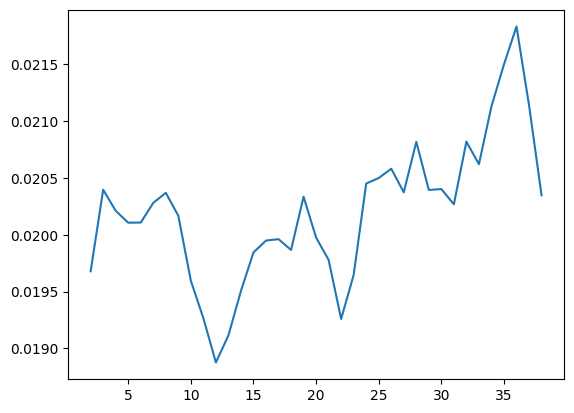

In [6]:
plt.plot(range(2,len(S_vals)), S_vals[2:])